# Overall Topic Analysis of Debate(Hansard) Data

In [1]:
import pandas as pd, numpy as np
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

df = pd.read_csv("data/canada_hansard_2022-2026.csv")

# anonymize speakers
mapping = {name: f"P{i:03d}" for i, name in enumerate(df["person"].unique(), start=1)}
df["person"] = df["person"].map(mapping)

# r.time is a Unix timestamp (auto-detect seconds vs milliseconds)
t = pd.to_numeric(df["r.time"], errors="coerce")
unit = "ms" if t.dropna().median() > 1e11 else "s"
df["date"] = pd.to_datetime(t, unit=unit, errors="coerce")
df = df.dropna(subset=["date", "topic", "person"]).copy()
df["year"] = df["date"].dt.year
df["quarter"] = df["date"].dt.to_period("Q")

print(df.shape, df["date"].min().date(), "to", df["date"].max().date())
df[["topic", "person", "date"]].sort_values(by="date", ascending=False)

(266380, 9) 2022-01-31 to 2026-06-18


,topic,person,date
78538,Taxes,P131,2026-06-18 20:35:00
78539,Elections,P131,2026-06-18 20:35:00
125018,Public finance,P053,2026-06-18 20:35:00
125019,Public service,P053,2026-06-18 20:35:00
17495,Claims,P316,2026-06-18 20:34:00
...,...,...,...
116787,Housing,P051,2022-01-31 16:15:00
93318,Inflation,P403,2022-01-31 16:14:00
261041,Housing assistance,P467,2022-01-31 16:05:00
261040,Community development,P467,2022-01-31 16:05:00


In [2]:
def attention(d):
    """Share of activity (%) per topic; each record = one unit of activity."""
    return d["topic"].value_counts(normalize=True) * 100

overall = attention(df)
overall.head(10).round(2)

topic
Public administration      3.44
Elections                  2.51
Housing                    2.15
Public service             1.88
Taxes                      1.52
Public finance             1.18
Aid programs               1.15
Justice system             1.10
Economic issues            1.08
Provincial institutions    1.06
Name: proportion, dtype: float64

In [3]:
# Current period = most recent 4 full quarters ending at the last date;
# historical norm = the average quarterly share across all earlier quarters.
last_q = df["quarter"].max()
current_qs = [last_q - i for i in range(4)]
cur = df[df["quarter"].isin(current_qs)]
hist = df[~df["quarter"].isin(current_qs)]

# Historical norm: mean of per-quarter shares (each quarter weighted equally)
hist_q = (hist.groupby("quarter")["topic"]
              .value_counts(normalize=True).mul(100)
              .unstack(fill_value=0))
norm = hist_q.mean()
current = attention(cur)

shift = (pd.concat([current.rename("current_%"), norm.rename("historical_norm_%")], axis=1)
           .fillna(0))
shift["shift_pp"] = shift["current_%"] - shift["historical_norm_%"]
shift = shift.sort_values("shift_pp", key=abs, ascending=False)
shift.round(2)

,current_%,historical_norm_%,shift_pp
topic,,,
Climate change,0.35,1.23,-0.89
Economic development,1.40,0.59,0.81
Justice system,1.72,0.92,0.80
Housing,1.67,2.41,-0.74
Elections,1.90,2.58,-0.68
...,...,...,...
Experiments,0.01,0.01,-0.00
Weather forecasts,0.00,0.00,0.00
Shoe industry,0.01,0.01,0.00


In [4]:
top3 = overall.head(5)
print("Top 3 topics:", ", ".join(f"{k} ({v:.2f}%)" for k, v in top3.items()))
print(f"HEADLINE 2a: The top three topics take {top3.sum():.2f}% of all legislative attention "
      f"(across {overall.size} topics).")

# Same measure in the current window vs. history
t3_cur = current.head(5).sum()
t3_hist = norm.sort_values(ascending=False).head(3).sum()
print(f"Top-3 concentration: current {t3_cur:.2f}% vs. historical norm {t3_hist:.2f}% "
      f"({t3_cur - t3_hist:+.2f} pp)")

Top 3 topics: Public administration (3.44%), Elections (2.51%), Housing (2.15%), Public service (1.88%), Taxes (1.52%)
HEADLINE 2a: The top three topics take 11.50% of all legislative attention (across 1324 topics).
Top-3 concentration: current 10.04% vs. historical norm 8.46% (+1.58 pp)


In [5]:
topic_share = (df["topic"].value_counts()
                 .rename_axis("topic")
                 .reset_index(name="records"))
topic_share["share_%"] = (topic_share["records"] / len(df) * 100).round(3)
topic_share["cumulative_%"] = topic_share["share_%"].cumsum().round(3)
topic_share.insert(0, "rank", range(1, len(topic_share) + 1))

print(f"{len(topic_share):,} distinct topics across {len(df):,} records")
topic_share

1,324 distinct topics across 266,380 records


,rank,topic,records,share_%,cumulative_%
0,1,Public administration,9164,3.440,3.440
1,2,Elections,6691,2.512,5.952
2,3,Housing,5725,2.149,8.101
3,4,Public service,5015,1.883,9.984
4,5,Taxes,4048,1.520,11.504
...,...,...,...,...,...
1319,1320,Learning disabilities,1,0.000,100.044
1320,1321,Real property services,1,0.000,100.044
1321,1322,Virtual exhibitions,1,0.000,100.044
1322,1323,Tsunamis,1,0.000,100.044


In [6]:
df["month"] = df["date"].dt.to_period("M")
df.sort_values(by="month", ascending=False)

# Monthly share (%) of all activity going to each topic
monthly = (df.groupby("month")["topic"]
             .value_counts(normalize=True).mul(100)
             .unstack(fill_value=0))
monthly.index = monthly.index.to_timestamp()

N_TOP = 3
top_topics = overall.head(N_TOP).index.tolist()
monthly[top_topics].round(2)


topic,Public administration,Elections,Housing
month,,,
2022-01-01,3.74,1.30,4.55
2022-02-01,4.23,2.15,1.39
2022-03-01,2.71,1.77,2.20
2022-04-01,2.78,1.11,3.12
2022-05-01,3.19,1.99,1.79
2022-06-01,3.17,2.61,0.90
2022-09-01,2.44,0.97,1.83
2022-10-01,2.70,1.55,1.51
2022-11-01,3.22,2.09,1.46


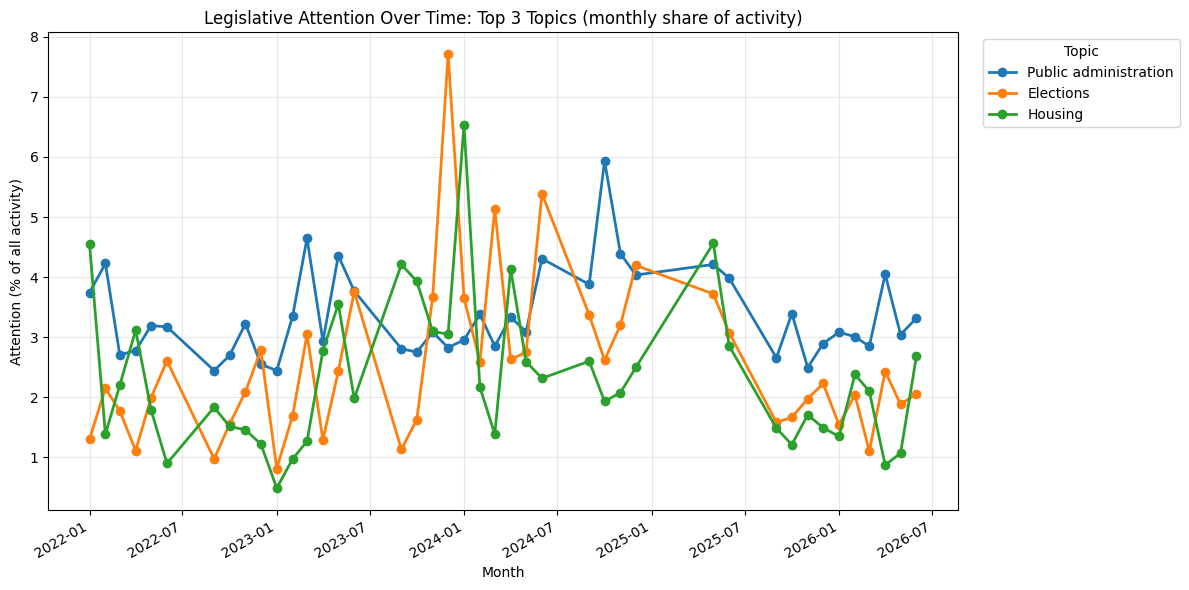

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
for t in top_topics:
    ax.plot(monthly.index, monthly[t], marker="o", linewidth=2, label=t)

ax.set_title(f"Legislative Attention Over Time: Top {N_TOP} Topics (monthly share of activity)")
ax.set_xlabel("Month")
ax.set_ylabel("Attention (% of all activity)")
ax.grid(alpha=0.3)
ax.legend(title="Topic", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# Specific Topic Analysis (Tariffs)

In [ ]:
discover = r"tariff|steel|alumin|dut(y|ies)|dumping|countervail|softwood|lumber|trade|protectionis|retaliat|CUSMA|NAFTA|USMCA|export|import|customs"
hits = df[df["topic"].str.contains(discover, case=False, regex=True, na=False)]

print(f"{len(hits):,} of {len(df):,} records ({len(hits)/len(df)*100:.2f}%) match the broad net\n")
hits["topic"].value_counts().head(40)

In [ ]:
def norm(s):
    return s.astype(str).str.strip().str.lower()

t = norm(df["topic"])

# Exact topic labels, taken from the Cell 17 output
THEMES = {
    "Tariffs":                        ["tariffs"],
    "Steel":                          ["steel"],
    "Lumber industry":                ["lumber industry"],
    "Trade negotiations & free trade": ["trade negotiations", "free trade"],
}
# Wider trade context, reported separately and NOT counted in the tariff family
BROAD = ["international trade", "exports", "imports", "trade"]
# Deliberately excluded (matched "trade" but are not about tariffs):
#   retail trade, domestic trade, wholesale trade, trademarks, trade shows

for name, labels in THEMES.items():
    df[name] = t.isin(labels)

theme_cols = list(THEMES)

# Lumber is mostly about the softwood dispute, but the label can also cover forestry/industry talk.
# Set to False to keep it out of the family total (it is still analysed as its own theme).
INCLUDE_LUMBER_IN_FAMILY = True
family_cols = [c for c in theme_cols if INCLUDE_LUMBER_IN_FAMILY or c != "Lumber industry"]

df["tariff_family"] = df[family_cols].any(axis=1)
df["broad_trade"]   = t.isin(BROAD)

# Coverage check
for name in theme_cols + ["tariff_family", "broad_trade"]:
    print(f"{name:34s} {df[name].sum():>6,} records  ({df[name].mean()*100:.3f}% of all activity)")

Tariffs                               808 records  (0.303% of all activity)
Steel                                  60 records  (0.023% of all activity)
Lumber industry                       289 records  (0.108% of all activity)
Trade negotiations & free trade       635 records  (0.238% of all activity)
tariff_family                       1,792 records  (0.673% of all activity)
broad_trade                         1,008 records  (0.378% of all activity)


In [ ]:
total = len(df)
rows = []
for name in theme_cols + ["tariff_family", "broad_trade"]:
    sub = df[df[name]]
    if sub.empty:
        rows.append([name, 0, 0.0, None, None, None]); continue
    by_month = sub.groupby("month").size()
    rows.append([name, len(sub), len(sub) / total * 100,
                 sub["date"].min().date(), sub["date"].max().date(), str(by_month.idxmax())])

summary = pd.DataFrame(rows, columns=["theme", "records", "share_%", "first_seen", "last_seen", "peak_month"])
summary["share_%"] = summary["share_%"].round(3)
summary

,theme,records,share_%,first_seen,last_seen,peak_month
0,Tariffs,808,0.303,2022-02-18,2026-06-18,2025-06
1,Steel,60,0.023,2023-03-24,2026-06-15,2025-06
2,Lumber industry,289,0.108,2022-02-01,2026-06-18,2025-11
3,Trade negotiations & free trade,635,0.238,2022-01-31,2026-06-18,2023-10
4,tariff_family,1792,0.673,2022-01-31,2026-06-18,2025-06
5,broad_trade,1008,0.378,2022-02-01,2026-06-18,2026-03


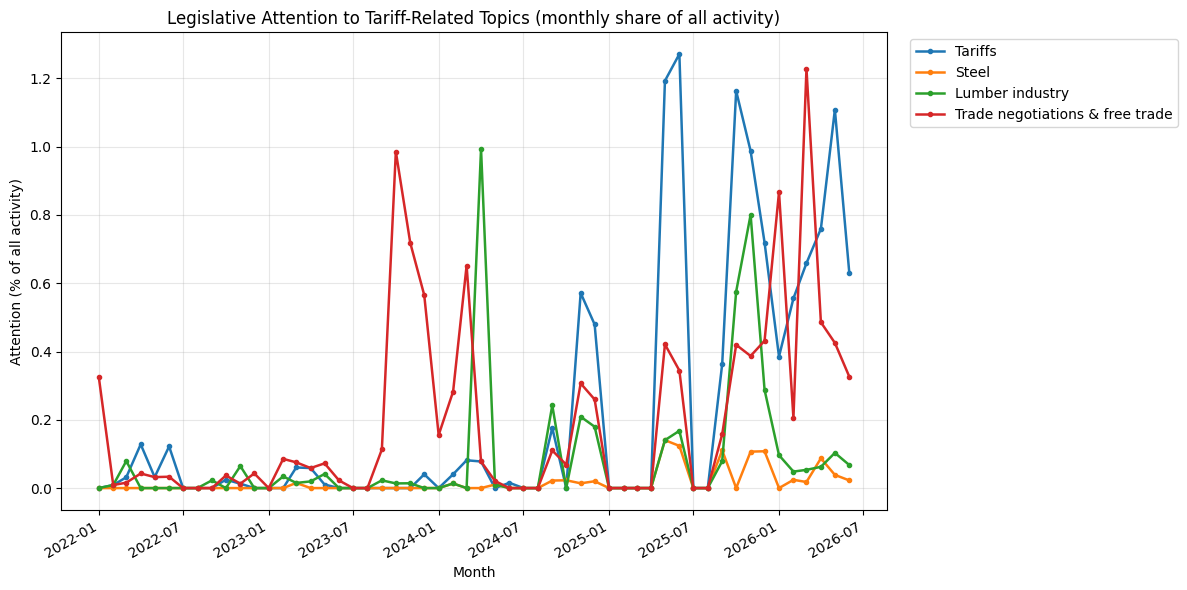

In [ ]:
all_months = pd.period_range(df["month"].min(), df["month"].max(), freq="M")
monthly_total = df.groupby("month").size().reindex(all_months, fill_value=0)

def monthly_share(mask):
    n = df[mask].groupby("month").size().reindex(all_months, fill_value=0)
    return (n / monthly_total.replace(0, np.nan) * 100).fillna(0)

share = pd.DataFrame({name: monthly_share(df[name]) for name in theme_cols})
share.index = share.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 6))
for c in theme_cols:
    ax.plot(share.index, share[c], marker="o", markersize=3, linewidth=1.8, label=c)
ax.set_title("Legislative Attention to Tariff-Related Topics (monthly share of all activity)")
ax.set_xlabel("Month"); ax.set_ylabel("Attention (% of all activity)")
ax.grid(alpha=0.3); ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

In [ ]:
# Monthly Tariff share dataframe
share

,Tariffs,Steel,Lumber industry,Trade negotiations & free trade
2022-01-01,0.000000,0.000000,0.000000,0.325203
2022-02-01,0.008881,0.000000,0.008881,0.008881
2022-03-01,0.031646,0.000000,0.079114,0.015823
2022-04-01,0.128205,0.000000,0.000000,0.042735
2022-05-01,0.032144,0.000000,0.000000,0.032144
2022-06-01,0.122019,0.000000,0.000000,0.033278
2022-07-01,0.000000,0.000000,0.000000,0.000000
2022-08-01,0.000000,0.000000,0.000000,0.000000
2022-09-01,0.000000,0.000000,0.022630,0.000000
2022-10-01,0.024624,0.000000,0.000000,0.036937


In [ ]:
df["quarter"] = df["date"].dt.to_period("Q")
last_q = df["quarter"].max()
current_qs = [last_q - i for i in range(4)]

def norm_vs_current(col):
    q = df.groupby("quarter")[col].mean() * 100
    cur = q[q.index.isin(current_qs)].mean()
    hist = q[~q.index.isin(current_qs)].mean()
    return hist, cur, cur - hist

out = pd.DataFrame(
    {n: norm_vs_current(n) for n in theme_cols + ["tariff_family", "broad_trade"]},
    index=["historical_norm_%", "current_%", "shift_pp"]).T
out.round(3)

,historical_norm_%,current_%,shift_pp
Tariffs,0.153,0.686,0.532
Steel,0.014,0.061,0.046
Lumber industry,0.072,0.198,0.126
Trade negotiations & free trade,0.165,0.407,0.243
tariff_family,0.404,1.352,0.948
broad_trade,0.213,0.758,0.544


Chamber average: 0.673% of records are tariff-related

Top 10 by volume:


,tariff_records,all_records,tariff_share_of_own_%,share_of_all_tariff_%,over_index_pp
person,,,,,
P066,93.0,10850,0.86,5.19,0.18
P019,76.0,5093,1.49,4.24,0.82
P146,63.0,969,6.50,3.52,5.83
P400,48.0,1217,3.94,2.68,3.27
P217,48.0,873,5.50,2.68,4.83
P128,34.0,1113,3.05,1.90,2.38
P164,32.0,542,5.90,1.79,5.23
P017,29.0,2195,1.32,1.62,0.65
P454,27.0,2337,1.16,1.51,0.48



Top 10 over-indexers (min 30 total records):


,tariff_records,all_records,tariff_share_of_own_%,share_of_all_tariff_%,over_index_pp
person,,,,,
P332,23.0,285,8.07,1.28,7.40
P087,3.0,44,6.82,0.17,6.15
P348,13.0,195,6.67,0.73,5.99
P146,63.0,969,6.50,3.52,5.83
P297,5.0,82,6.10,0.28,5.42
P164,32.0,542,5.90,1.79,5.23
P272,4.0,68,5.88,0.22,5.21
P431,10.0,178,5.62,0.56,4.95
P290,5.0,89,5.62,0.28,4.95


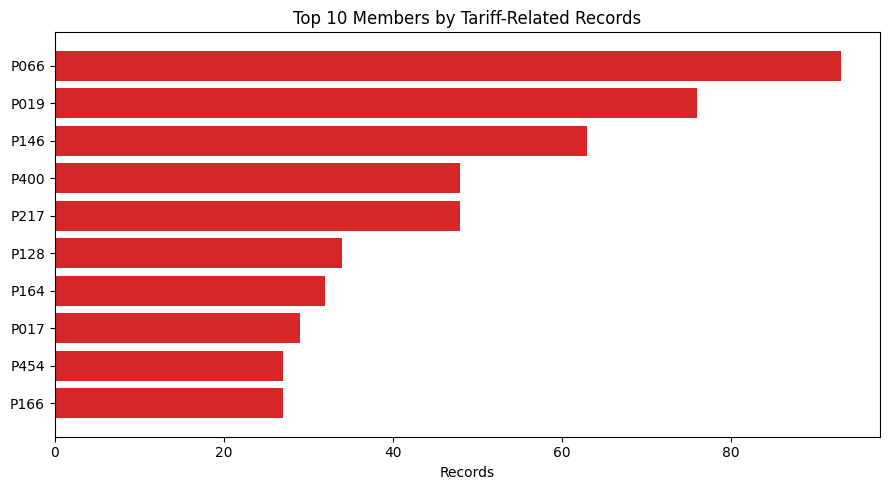

In [ ]:
fam_df = df[df["tariff_family"]]

member_total = df["person"].value_counts()
member_fam = fam_df["person"].value_counts()

members = pd.DataFrame({"tariff_records": member_fam, "all_records": member_total}).dropna()
members["tariff_share_of_own_%"] = members["tariff_records"] / members["all_records"] * 100
members["share_of_all_tariff_%"] = members["tariff_records"] / member_fam.sum() * 100
chamber_avg = df["tariff_family"].mean() * 100
members["over_index_pp"] = members["tariff_share_of_own_%"] - chamber_avg

print(f"Chamber average: {chamber_avg:.3f}% of records are tariff-related\n")
print("Top 10 by volume:")
display(members.sort_values("tariff_records", ascending=False).head(10).round(2))

print("\nTop 10 over-indexers (min 30 total records):")
display(members[members["all_records"] >= 30].sort_values("over_index_pp", ascending=False).head(10).round(2))

top10 = members.sort_values("tariff_records", ascending=False).head(10)[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10.index, top10["tariff_records"], color="tab:red")
ax.set_title("Top 10 Members by Tariff-Related Records"); ax.set_xlabel("Records")
plt.tight_layout(); plt.show()